<img src="https://media.giphy.com/media/FSzLVme5Y3n3LMOiqP/giphy.gif" width="250" height="250"/>


Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

## Questions

With your own data that you collected:
1. Create 2 graphs between two variables. Be sure to include the title, labels of both axis. Include a legend if necessary. Be sure that nothing overlaps in the graph (words or legends, etc). 

2. Write 1-2 sentences that describe the main information presented and a conclusion that you could draw from that graph. 

3. Display the graphs side by side in one figure. 

4. Do a third graph that is not a line graph or bar chart (with proper labels and titles). Make sure this third graph displays different information than presented in step 1.


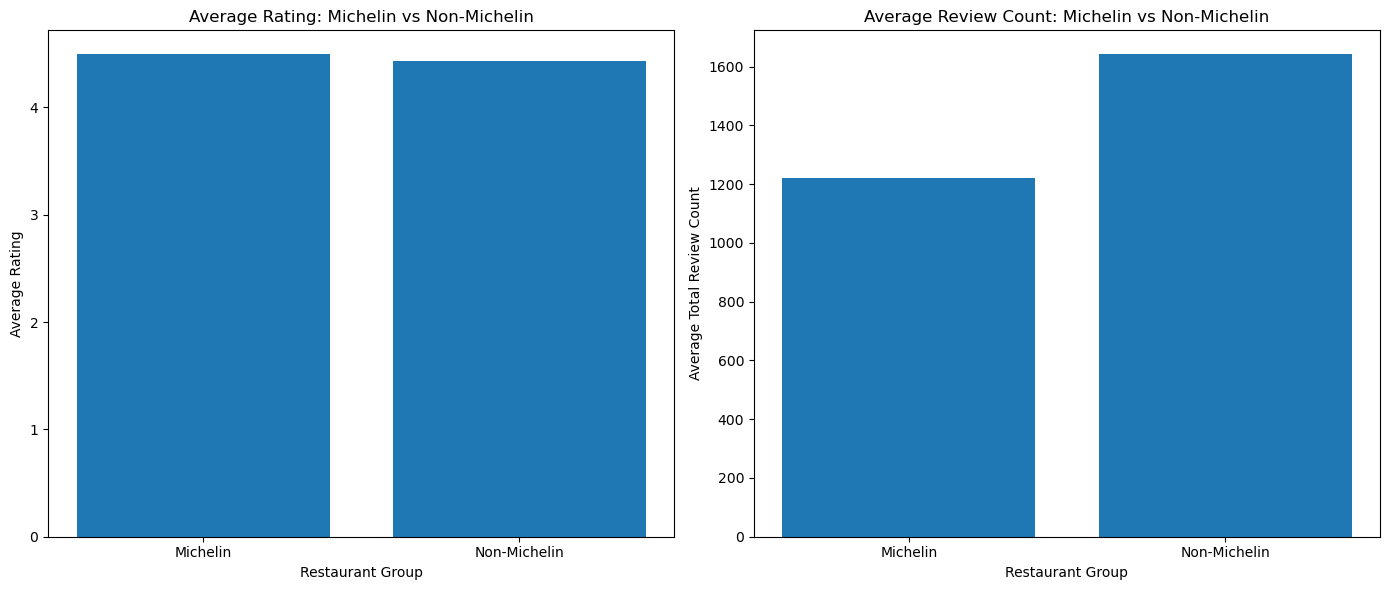

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
#BAR GRAPHS FOR RATINGS AND NUMBER OF RATINGS
# Create labels for binary variable for michelin distinction
analysis_df["michelin_group"] = analysis_df["michelin"].map({1: "Michelin", 0: "Non-Michelin"})

# Create figure with 2 graphs side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graph 1: Average rating by Michelin
avg_rating = analysis_df.groupby("michelin_group")["rating"].mean()

axes[0].bar(avg_rating.index, avg_rating.values)
axes[0].set_title("Average Rating: Michelin vs Non-Michelin")
axes[0].set_xlabel("Restaurant Group")
axes[0].set_ylabel("Average Rating")

# Graph 2: Average review count by Michelin 
avg_reviews = analysis_df.groupby("michelin_group")["review_count"].mean()

axes[1].bar(avg_reviews.index, avg_reviews.values)
axes[1].set_title("Average Review Count: Michelin vs Non-Michelin")
axes[1].set_xlabel("Restaurant Group")
axes[1].set_ylabel("Average Total Review Count")

plt.tight_layout()
plt.show()

In [ ]:
##In the first graph it is clear that there is not much of a difference in the average rating of restaurants, Michelin or not. 
##There is variation in the average number of ratings between Michelin and non-Michelin restaurants, with non-Michelin restaurants having 
##400 more reviews on average. This may have to do with the accessability of restaurants. 
##Non-Michelin restaurants may be easier to get reservations/walk in tables at, giving the oppurtunity for more people to dine there and 
##thus leave a review. Still, this difference in volume of reviews does not seem to have an affect on the average rating. 

In [25]:
analysis_df = pd.read_csv('analysis_df.csv') 

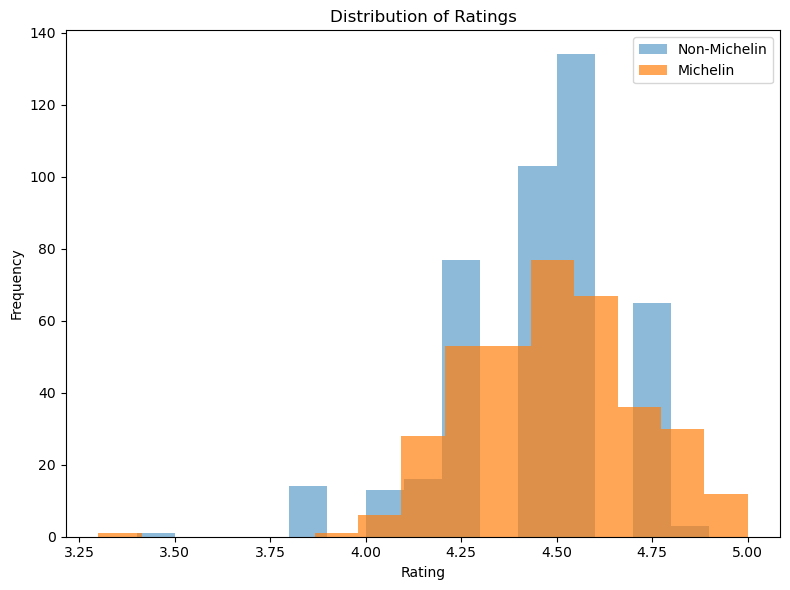

In [47]:
#HISTOGRAM FOR REVIEWS
plt.figure(figsize=(8,6))
#Histogram for non michelin restaurants 
plt.hist(
    analysis_df[analysis_df["michelin"] == 0]["rating"],
    bins=15,
    alpha=0.5,
    label="Non-Michelin"
)
#histogram for michelin restuarants
plt.hist(
    analysis_df[analysis_df["michelin"] == 1]["rating"],
    bins=15,
    alpha=0.7,
    label="Michelin"
)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
##Both distributions appear to be approximately normally distrbuted with a slight left-skew.
##There is substancial overlap between the two which suggests that Non-Michelin restaurants are able to receive similar reviews despite their
##lack of this specific accreditation. 

/var/folders/s_/gb9w7vjx5t3fsgklnlq7fnq80000gn/T/ipykernel_94123/2697430742.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


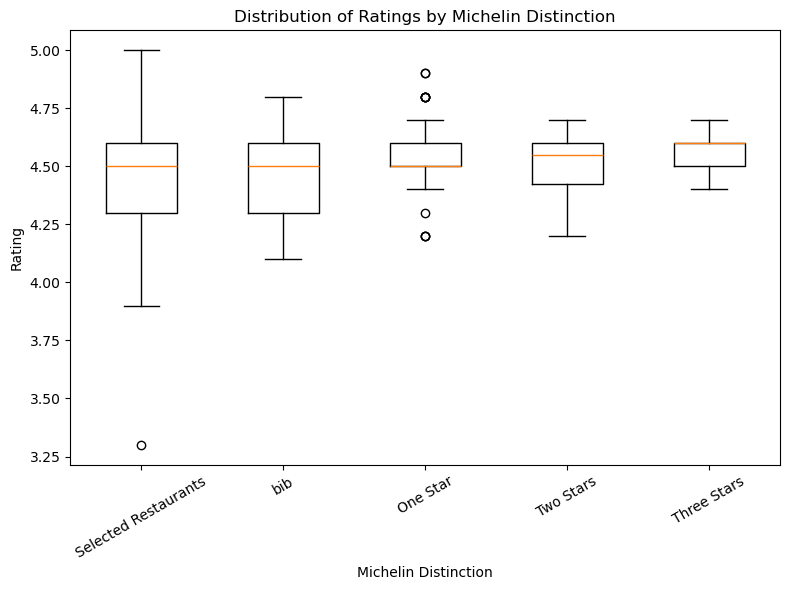

In [48]:
#MICHELIN ONLY GRAPHS
#BPLOT FOR MICHELIN CATEGORIES
# DF for only Michelin restaurants
michelin_only = analysis_df[analysis_df["michelin"] == 1]

# Removes one restaurant that has "Michelin Star" as the value for michelin_distincion
michelin_only = michelin_only[
    michelin_only["michelin_distinction"] != "Michelin Star"
]

plt.figure(figsize=(8, 6))

# Order the plots for asending level of recogniton
order = ["Selected Restaurants", "bib", "One Star", "Two Stars", "Three Stars"]

# Build data in that order
data = [
    michelin_only[michelin_only["michelin_distinction"] == d]["rating"].dropna()
    for d in order if d in michelin_only["michelin_distinction"].values
]
#label the plots accordingly
labels = [d for d in order if d in michelin_only["michelin_distinction"].values]

plt.boxplot(data, labels=labels)

plt.title("Distribution of Ratings by Michelin Distinction")
plt.xlabel("Michelin Distinction")
plt.ylabel("Rating")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

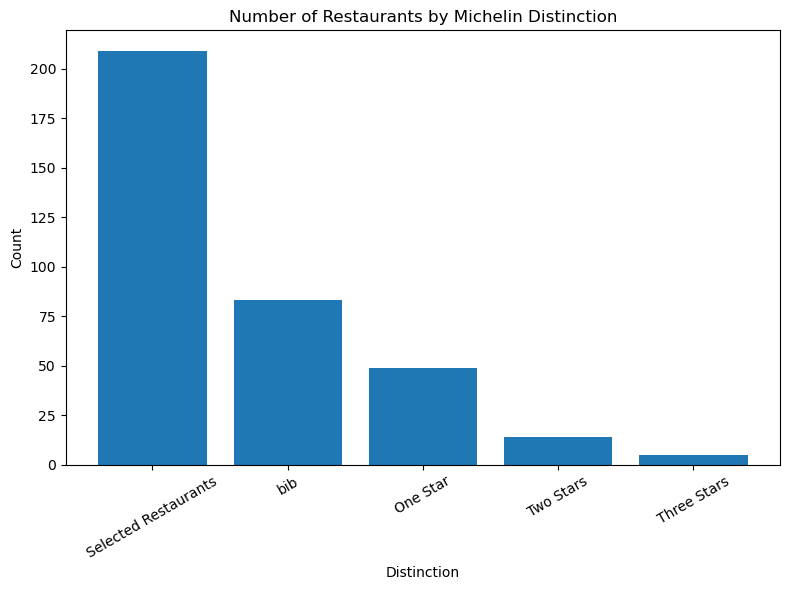

In [36]:
michelin_only = analysis_df[analysis_df["michelin"] == 1]

# Removes one restaurant that has "Michelin Star" as the value for michelin_distincion
michelin_only = michelin_only[
    michelin_only["michelin_distinction"] != "Michelin Star"
]

# Counts the number of restaurants in each category 
counts = michelin_only["michelin_distinction"].value_counts()

plt.figure(figsize=(8,6))
plt.bar(counts.index, counts.values)

plt.title("Number of Restaurants by Michelin Distinction")
plt.xlabel("Distinction")
plt.ylabel("Count")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
##Ratings are generally high no matter the level of Michelin recognition, but the higher-star restaurants have slightly higher medians and less variation. 
##The lower categories, like Selected Restaurants and Bib Gourmand, have a wider spread and a few lower ratings mixed in. 
##There are also far more restaurants in the lower categories than at the top, so the tighter ratings for 2 and 3 star spots come from a much smaller group.